In [5]:
from config import DATASET_DIR
from data import DataLoader
from features import ResNetFeatureExtractor
from summarizer import KMeansSummarizer, LSTMSummarizer, SupervisedSummarizer
from visualization import plot_keyframes, plot_feature_projection

import warnings
warnings.filterwarnings('ignore')

In [6]:
# Setup Data Loader and Feature Extractor
loader = DataLoader(DATASET_DIR)
features_extractor = ResNetFeatureExtractor()
video_id = 'AwmHb44_ouw'
video_path = f'{DATASET_DIR}/ydata-tvsum50-video/video/{video_id}.mp4'

--- ResNet + KMeans Approach ---
Saved keyframes plot to results/AwmHb44_ouw_kmeans_keyframes.png


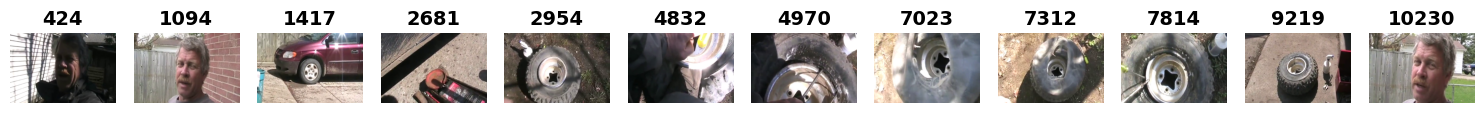

Plotting 12 clusters...
Saved PCA plot to results/AwmHb44_ouw_kmeans_pca.png


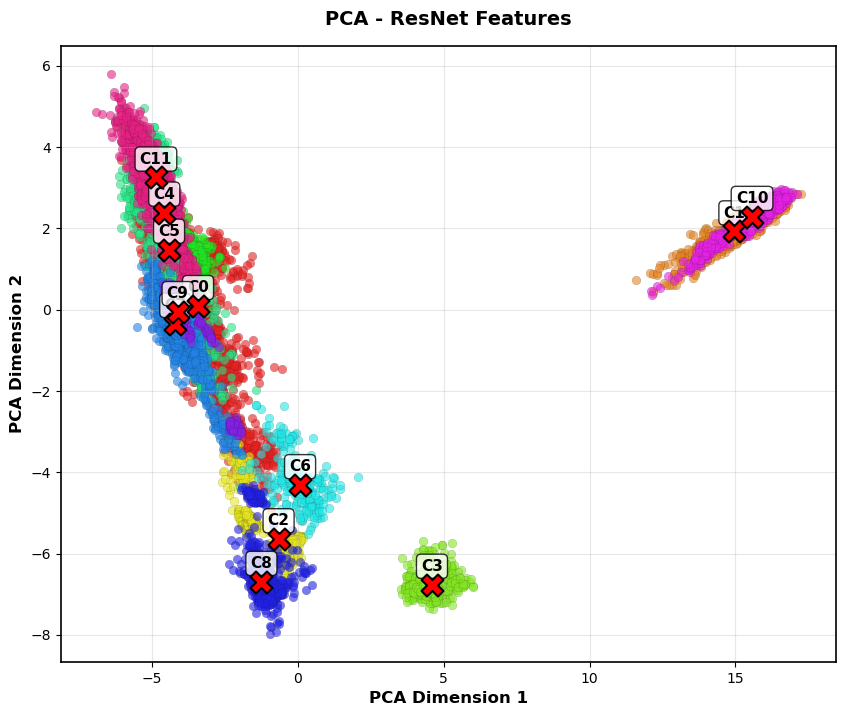

Plotting 12 clusters...
Saved TSNE plot to results/AwmHb44_ouw_kmeans_tsne.png


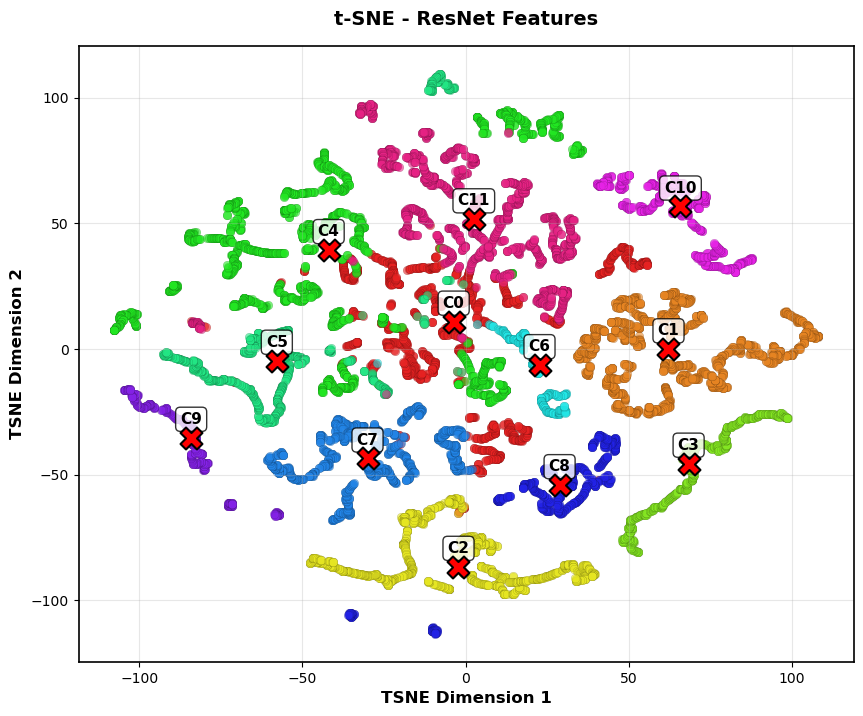

In [7]:
# 1. ResNet + KMeans Approach
print("--- ResNet + KMeans Approach ---")
kmeans_summ = KMeansSummarizer(loader, features_extractor)
key_indices_kmeans, kmeans_labels = kmeans_summ.summarize(video_id)

plot_keyframes(video_path, key_indices_kmeans, output_filename=f"{video_id}_kmeans_keyframes.png")
plot_feature_projection(kmeans_summ.all_features, labels=kmeans_labels, method='pca', title='PCA - ResNet Features', output_filename=f"{video_id}_kmeans_pca.png")
plot_feature_projection(kmeans_summ.all_features, labels=kmeans_labels, method='tsne', title='t-SNE - ResNet Features', output_filename=f"{video_id}_kmeans_tsne.png")


--- LSTM Autoencoder + KMeans Approach ---


/home/osama_ashraf/miniconda3/envs/dl-env/lib/python3.10/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


Saved keyframes plot to results/AwmHb44_ouw_lstm_keyframes.png


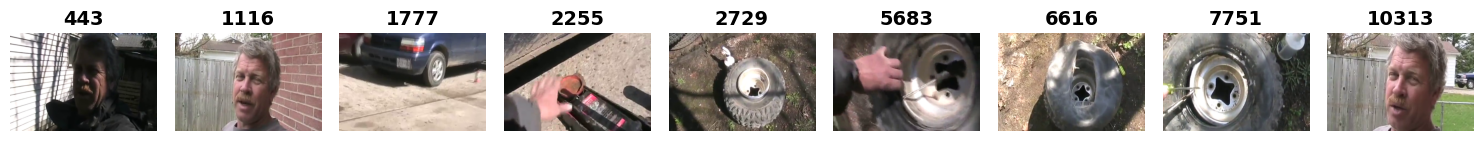

Plotting 9 clusters...
Saved PCA plot to results/AwmHb44_ouw_lstm_pca.png


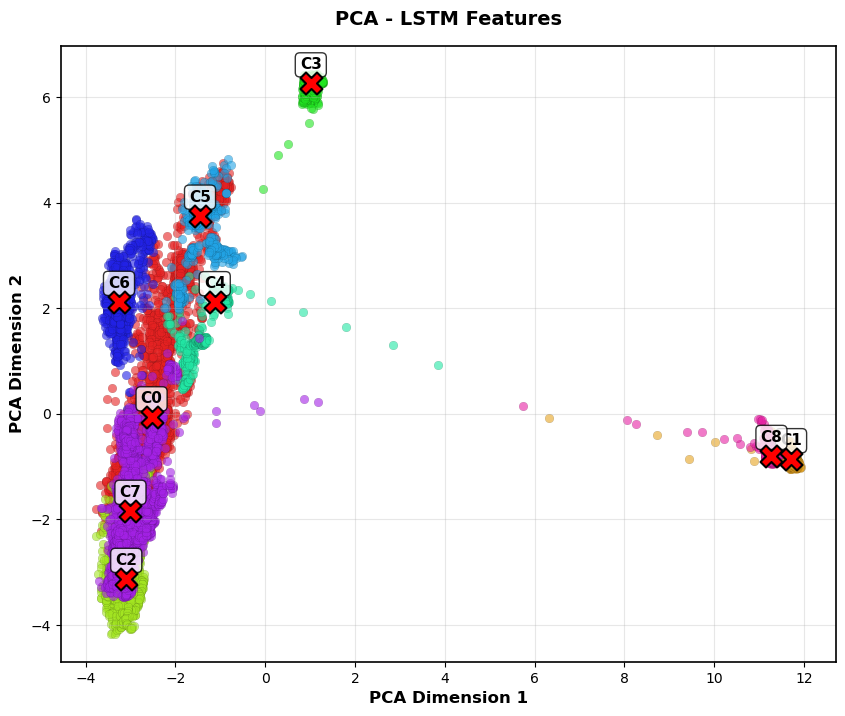

Plotting 9 clusters...
Saved TSNE plot to results/AwmHb44_ouw_lstm_tsne.png


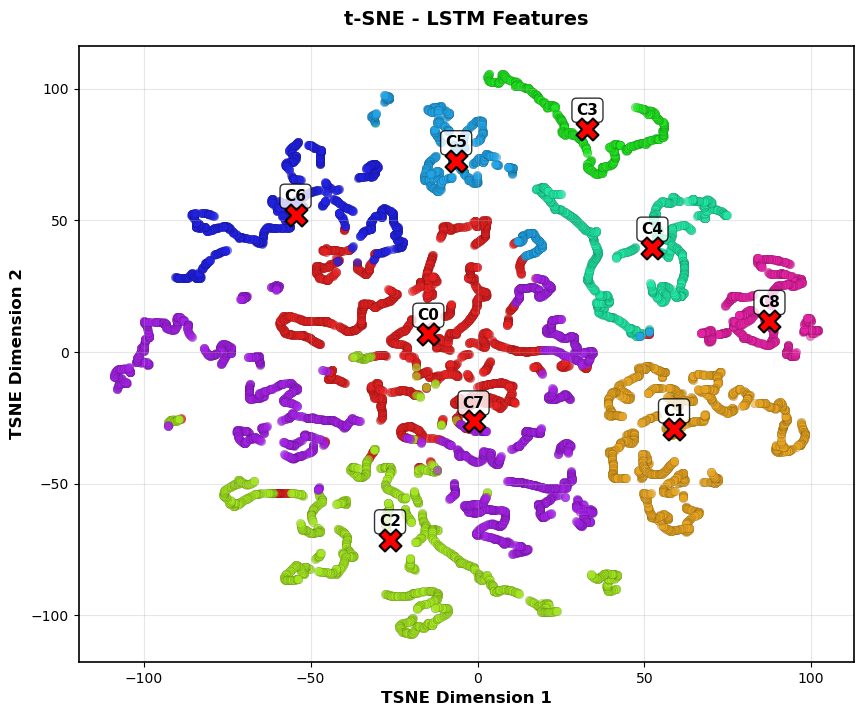

In [ ]:
# 2. LSTM Autoencoder + KMeans Approach
print("\n--- LSTM Autoencoder + KMeans Approach ---")
lstm_summ = LSTMSummarizer(loader, features_extractor)
key_indices_lstm, lstm_labels = lstm_summ.summarize(video_id)

plot_keyframes(video_path, key_indices_lstm, output_filename=f"{video_id}_lstm_keyframes.png")
plot_feature_projection(lstm_summ.lstm_features, labels=lstm_labels, method='pca', title='PCA - LSTM Features', output_filename=f"{video_id}_lstm_pca.png")
plot_feature_projection(lstm_summ.lstm_features, labels=lstm_labels, method='tsne', title='t-SNE - LSTM Features', output_filename=f"{video_id}_lstm_tsne.png")


--- Supervised BiLSTM Predictor Approach ---


Precomputing features: 100%|██████████| 50/50 [22:47<00:00, 27.34s/it]


Epoch 1/10 | Loss: 0.06307


Epoch 2/10 | Loss: 0.04559


Epoch 3/10 | Loss: 0.03769


...

Epoch 6/10 | Loss: 0.02596


Epoch 7/10 | Loss: 0.02517


Epoch 8/10 | Loss: 0.02567


Epoch 9/10 | Loss: 0.02555


Epoch 10/10 | Loss: 0.02369
Saving supervised model weights to supervised_model_weights.pth...
Saved keyframes plot to results/AwmHb44_ouw_supervised_keyframes.png


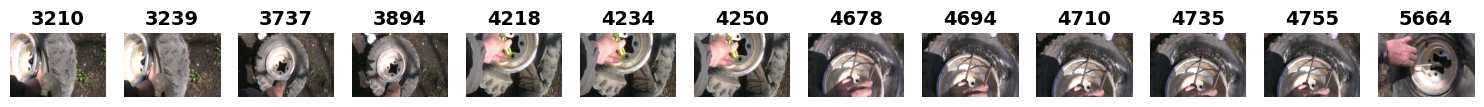

In [4]:
# 3. Supervised BiLSTM Predictor Approach
print("\n--- Supervised BiLSTM Predictor Approach ---")
supervised_summ = SupervisedSummarizer(loader, features_extractor)
supervised_summ.train_on_dataset(epochs=10)
key_indices_sup, sup_labels = supervised_summ.summarize(video_id, num_frames=13)

plot_keyframes(video_path, key_indices_sup, output_filename=f"{video_id}_supervised_keyframes.png")